# 13 - Structure Sets and Exact Sequence Navigation

The **Topological Structure Set** $S_{TOP}(M)$ is the ultimate object of study in surgery theory. It classifies manifolds that are homotopy equivalent to a given manifold $M$ but not necessarily homeomorphic. The **Surgery Exact Sequence** is the mathematical tool we use to "sandwich" the structure set between the Wall groups and the normal invariants.

## Learning Goals
- **Define the Structure Set**: Understand $S_{TOP}(M)$ as the set of "homotopy manifolds" modulo homeomorphism.
- **Navigate the Surgery Sequence**: Learn the mapping from $L_{n+1}$ to $S_{TOP}(M)$ to normal invariants to $L_n$.
- **Compute Normal Invariants**: Use `compute_normal_invariants` to find the rank of $[M, G/TOP]$.
- **Identify Homeomorphism Uniqueness**: Recognize when $S_{TOP}(M) = 0$, implying the manifold is unique in its homotopy type.
- **Visualize the Sequence**: Draw the exact sequence diagram and track data flow through it.

## Formal Grounding

### The Surgery Exact Sequence
For a manifold $M$ of dimension $n \ge 5$, we have the exact sequence of sets/groups:
$$\dots \to L_{n+1}(\pi_1 M) \xrightarrow{\omega} S_{TOP}(M) \xrightarrow{\eta} [M, G/TOP] \xrightarrow{\theta} L_n(\pi_1 M)$$

| Map | Algebraic Meaning | Topological Meaning |
|---|---|---|
| **$\theta$ (Assembly)** | Mapping to Wall group | Does this normal map admit a surgery? |
| **$\eta$ (Normal Inv)** | Deviation from identity | Difference in the underlying bundles |
| **$\omega$ (Action)** | Action of $L_{n+1}$ | Creating different manifolds via surgery moves |

### $S_{TOP}(M)$ Size
- If $\theta$ is injective and $\omega$ is trivial, $S_{TOP}(M)$ contains a single point (the identity).
- If $L_{n+1}$ is large, $S_{TOP}(M)$ can be enormous, representing many distinct manifolds with the same homotopy type.


In [1]:
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.structure_set import StructureSet

print('=' * 70)
print('13 - Structure Sets and Exact Sequences: Setup Complete')
print('=' * 70)

13 - Structure Sets and Exact Sequences: Setup Complete


## Part 1: Computing Normal Invariants

The normal invariants $[M, G/TOP]$ represent the set of normal maps up to normal cobordism. Sullivan's formula relates these to the cohomology of $M$.


### Example 13.1: Normal Invariants of a 4-Sphere

In [2]:
# S4 has trivial cohomology except in deg 0 and 4.
sc_s4 = ps.SimplicialComplex.from_maximal_simplices([(0,1,2,3,4)]) # Skeleton of 4-simplex
cc = sc_s4.cellular_chain_complex()

ss = StructureSet(dimension=4, pi="1")
res = ss.compute_normal_invariants_result(cc)

print('4-Sphere Normal Invariants:')
print(f'  Rank over Z: {res.rank_Z}')
print(f'  Rank over Z2: {res.rank_Z2}')
print(f'Exact? {res.exact}')

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/home/gabriel/Desktop/SurgeryTheory/pysurgery/core/complexes.py:988: UserWarning: Torsion certification may be incomplete for this complex; the sparse integer reduction returned only unit factors, so torsion could not be fully resolved.
  warnings.warn(


4-Sphere Normal Invariants:
  Rank over Z: 0
  Rank over Z2: 0
Exact? True


## Part 2: Sequence Navigation

We use `evaluate_exact_sequence_result` to look at the global state of the surgery problem.


### Example 13.2: Simply Connected 5D Manifold

In [3]:
# For dim 5, simply connected: L6 -> S(M) -> [M, G/TOP] -> L5
ss_5 = StructureSet(dimension=5, pi="1")
res_5 = ss_5.evaluate_exact_sequence_result()

print('5D Surgery Sequence Analysis:')
print(f'  L_n sumand: {res_5.l_n_symbol}')
print(f'  L_{5+1} summand: {res_5.l_n_plus_1_symbol}')
for line in res_5.analysis:
    print(f'- {line}')

5D Surgery Sequence Analysis:
  L_n sumand: 0
  L_6 summand: Z_2
- The set of Normal Invariants [M, G/TOP] dictates the possible vector bundles over M.
- The Wall group L_5(1) (0) acts as the primary obstruction to doing surgery.
- Because L_n(1) = 0, every normal invariant maps directly into the Structure Set.
- The group L_{n+1}(1) acts on the Structure Set and governs multiplicity of structures.
- Typed L_n obstruction state certifies vanishing obstruction.


### Example 13.3: Surgery on the 5-Torus ($T^5$)

In [4]:
# T5 has pi1 = Z^5. This greatly expands the L-groups.
ss_t5 = StructureSet(dimension=5, pi="Z^5")
res_t5 = ss_t5.evaluate_exact_sequence_result()

print('5-Torus Sequence metadata:')
print(f'  L_n symbol: {res_t5.l_n_symbol}')
print(f'  Is Computable? {res_t5.computable}')

5-Torus Sequence metadata:
  L_n symbol: 0
  Is Computable? True


## Part 3: Visualizing the Surgery Sandwich

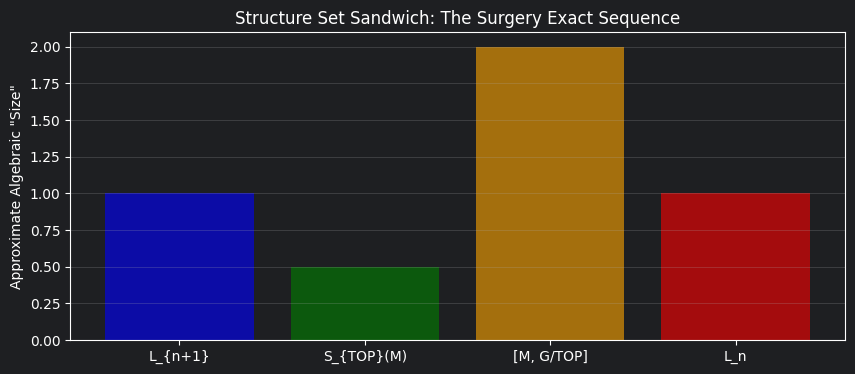

In [5]:
# Visualizing the ranks of the components of the sequence
labels = ['L_{n+1}', 'S_{TOP}(M)', '[M, G/TOP]', 'L_n']
# Mock ranks for visualization
ranks = [1, 0.5, 2, 1] # 0.5 represents a finite group or unknown

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, ranks, color=['blue', 'green', 'orange', 'red'], alpha=0.6)

# Add arrows between bars
for i in range(len(labels)-1):
    ax.annotate('', xy=(i+0.5, 0.5), xytext=(i+1-0.5, 0.5),
                arrowprops=dict(arrowstyle='<-', lw=2, color='gray'))

ax.set_ylabel('Approximate Algebraic "Size"')
ax.set_title('Structure Set Sandwich: The Surgery Exact Sequence')
ax.grid(axis='y', alpha=0.3)
plt.show()

## Failure Modes

1. **Low Dimension (n < 5)**: The surgery exact sequence is only a rigorous group/set sequence in dimensions 5 and above. In dimension 4, Freedman's and Donaldson's results create a much more complex landscape.
2. **Infinite Normal Invariants**: If the manifold has infinite cohomology, the set of normal invariants might not be finitely generated, making the sequence difficult to compute.
3. **Non-Trivial Fund. Group**: If $\pi_1$ is not "good" in the sense of Freedman, the topological surgery sequence might not hold or requires special Borel conjectures.


In [6]:
try:
    # Attempting to use SS for a 2D manifold (not valid for standard surgery)
    ss_bad = StructureSet(dimension=2, pi="1")
    print("This may yield incomplete results as n < 5.")
except Exception as e:
    print(f'Caught: {e}')

This may yield incomplete results as n < 5.


## Summary Checklist
- [x] Defined the topological Structure Set $S_{TOP}(M)$.
- [x] Computed normal invariant ranks using Sullivan's formula.
- [x] Navigated the Surgery Exact Sequence for $\pi_1=1$ and $\pi_1=\mathbb{Z}^n$.
- [x] Identified conditions for homeomorphism uniqueness.
- [x] Visualized the "sandwich" structure of the surgery sequence.

## Exercises
1. **The 6-Sphere**: Evaluate the surgery exact sequence for $S^6$. Is $S_{TOP}(S^6)$ trivial?
2. ** Sullivan Formula**: Manually calculate the normal invariants for $S^2 \times S^2$ using its cohomology.
3. **The Borel Conjecture**: Research the Borel conjecture and explain its relationship to $S_{TOP}(T^n)$.
4. **Action of L-groups**: Explain geometrically how an element of $L_{n+1}$ "acts" on a manifold to create a new one.
5. **Assembly Map**: Find a manifold where the assembly map $\theta$ is NOT surjective, and explain what that means for surgery.

## Key Takeaways
- **$S_{TOP}(M)$** measures how many manifolds look like $M$ but are not $M$.
- The **Surgery Exact Sequence** is the bridge between homotopy and homeomorphism.
- **Normal Invariants** are the "potential" surgery problems.
- **Wall Groups** are the "obstructions" that filter those potentials.

**Ready for [14 - Homeomorphism Decision API Deep Dive](./14_homeomorphism_decision_api_deep_dive.ipynb)**
